In [4]:
#using https://spacetelescope.github.io/notebooks/notebooks/MAST/TESS/beginner_how_to_use_ffi/beginner_how_to_use_ffi.html

In [1]:
%matplotlib inline
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import numpy as np

In [2]:
fits_file = 'C:/Users/ktpha/Documents/TESSNeptune24/DIApython/cal/Wirtanen_1382.057359055837-1402.11971789867_15.0-x-10.0_astrocut.fits'

In [3]:
fits.info(fits_file)

Filename: C:/Users/ktpha/Documents/TESSNeptune24/DIApython/cal/Wirtanen_1382.057359055837-1402.11971789867_15.0-x-10.0_astrocut.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      55   ()      
  1  PIXELS        1 BinTableHDU    151   919R x 16C   [D, E, J, 150J, 150E, 150E, 150E, 150E, J, E, E, 38A, D, D, D, D]   
  2  APERTURE      1 ImageHDU        97   (2136, 2078)   int32   


In [5]:
with fits.open(fits_file, mode = "readonly") as hdulist:
    wcs_info = WCS(hdulist[1].header)
    cal_image = hdulist[1].data
    header = hdulist[1].header

Set MJD-END to 58408.879141 from DATE-END'. [astropy.wcs.wcs]


In [6]:
# Use the header to determine the mid-point of the exposure time for this FFI.
mid_time = (header['TSTOP'] + header['TSTART']) / 2

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (16,) + inhomogeneous part.

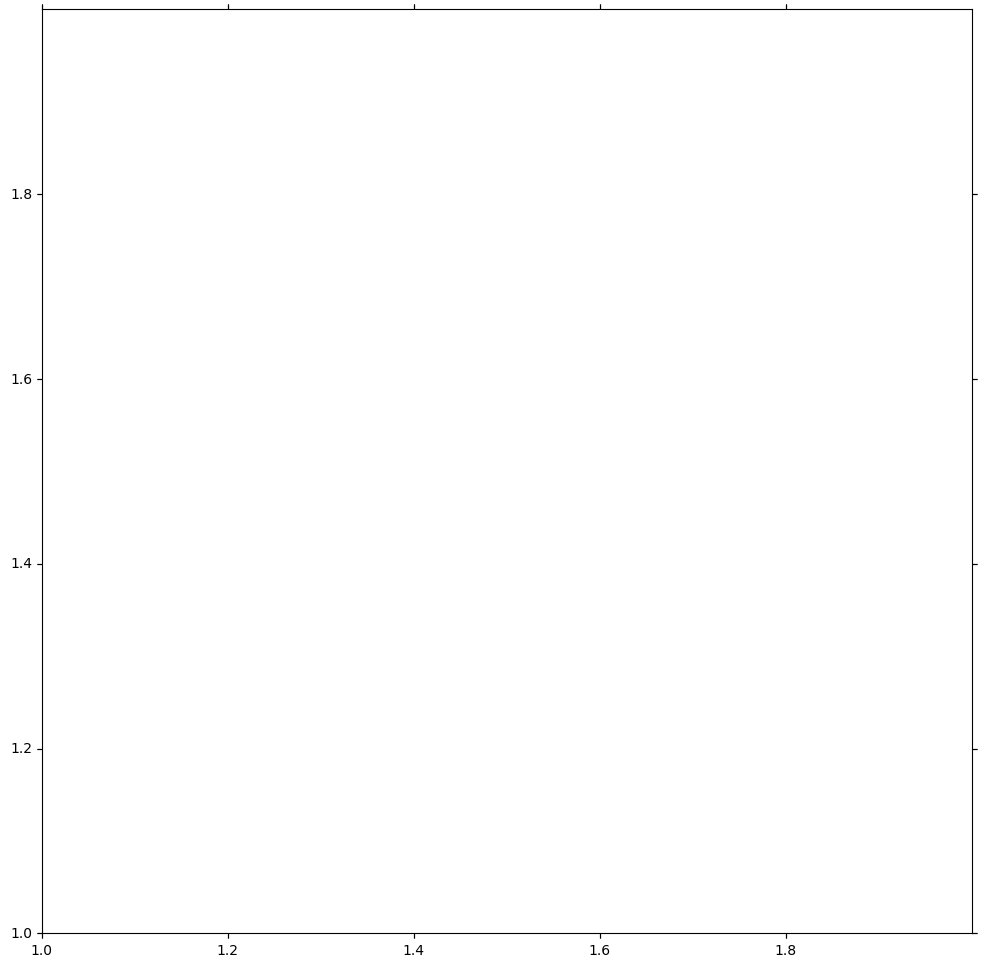

In [7]:
plt.figure(figsize = (12,12))

plt.subplot(111, projection = wcs_info)
plt.imshow(cal_image, vmin = np.percentile(cal_image,4),vmax = np.percentile(cal_image, 98),origin = "lower")
plt.xlabel('RA')
plt.ylabel('Dec')
plt.title("TESS Calibrated FFI for Sector 1, Camera 4, CCD 2, Timestamp %f BTJD" % mid_time)

cal_image.shape

In [9]:
##gpt
print("Shape of cal_image:", cal_image.shape)
print("Data type of cal_image:", cal_image.dtype)

Shape of cal_image: (919,)
Data type of cal_image: (numpy.record, [('TIME', '>f8'), ('TIMECORR', '>f4'), ('CADENCENO', '>i4'), ('RAW_CNTS', '>i4', (10, 15)), ('FLUX', '>f4', (10, 15)), ('FLUX_ERR', '>f4', (10, 15)), ('FLUX_BKG', '>f4', (10, 15)), ('FLUX_BKG_ERR', '>f4', (10, 15)), ('QUALITY', '>i4'), ('POS_CORR1', '>f4'), ('POS_CORR2', '>f4'), ('FFI_FILE', 'S38'), ('TGT_X', '>f8'), ('TGT_Y', '>f8'), ('TGT_RA', '>f8'), ('TGT_DEC', '>f8')])


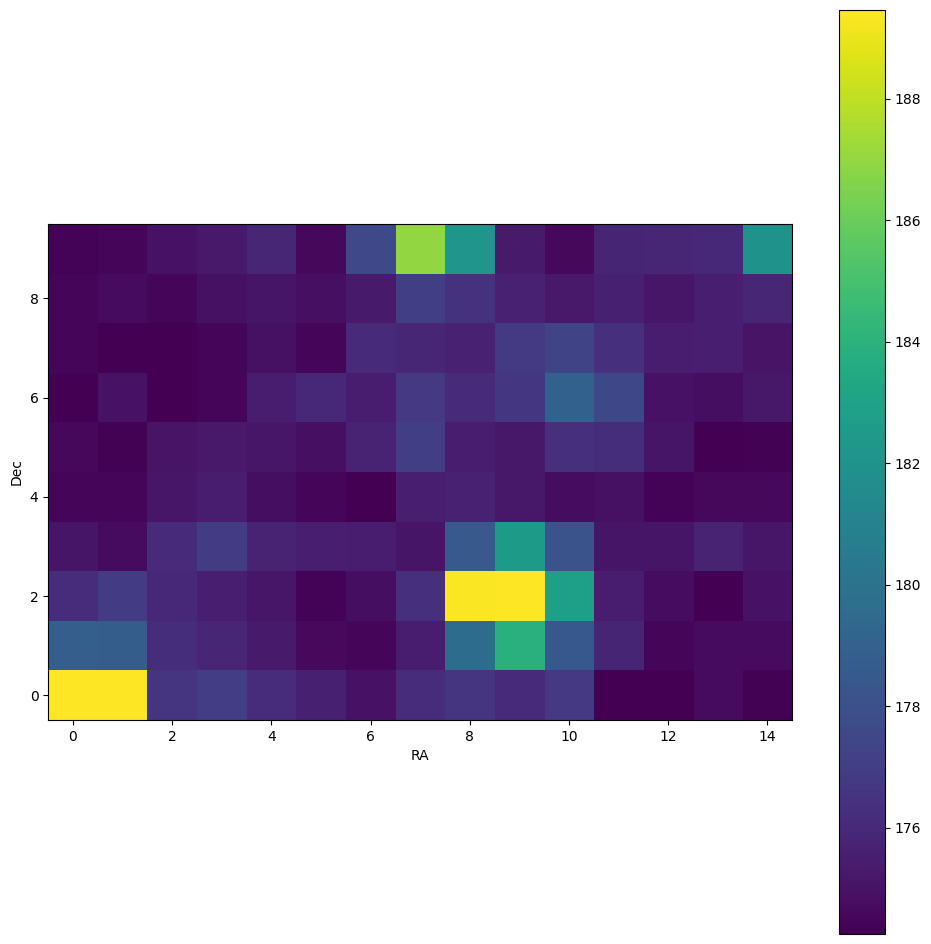

In [11]:
# Extract the 'FLUX' field from the structured array
flux_data = cal_image['FLUX'][0]

# Plot the image
plt.figure(figsize=(12, 12))
plt.imshow(flux_data, vmin=np.percentile(flux_data, 4), vmax=np.percentile(flux_data, 98), origin="lower")
plt.xlabel('RA')
plt.ylabel('Dec')
plt.colorbar()  # Add color bar if needed
plt.show()

In [12]:
web_fits = "https://mast.stsci.edu/tesscut/api/v0.1/moving_target/astrocut?obj_id=Wirtanen&y=15&x=10&units=px&sector=3"


In [14]:
fits.info(web_fits)


TimeoutError: The read operation timed out